In [1]:
import numpy,sklearn,sklearn.datasets
X,T = sklearn.datasets.load_breast_cancer(return_X_y=True)
X = (X - X.mean(axis=0)) / X.std(axis=0)
XM,XB = X[T==0],X[T==1]

I will create a function `w = fisher(X1,X2)` that takes as input the data for the two classes (two numpy arrays of size $N_1 \times d$ and $N_2 \times d$ respectively) and returns the Fisher linear discriminant.

In [2]:
def fisher(X1,X2):
    def stat(X):
        M = X.mean(axis=0)
        Xc = X-M
        SW = Xc.T.dot(Xc)
        return M, SW
    M1, SW1 = stat(X1)
    M2, SW2 = stat(X2)
    w  = numpy.linalg.inv(SW1+SW2).dot(M1-M2)
    w = w / (w**2).sum()**.5

    return w

Plot of the histogram of projected data for several projection vectors `w`, in particular

 1. `w` is the difference between the mean vectors of the two classes
 2. `w` is the Fisher discriminant, and
 3. `w` is the weight vector of a linear SVM (with hyperparameter C=10.0).

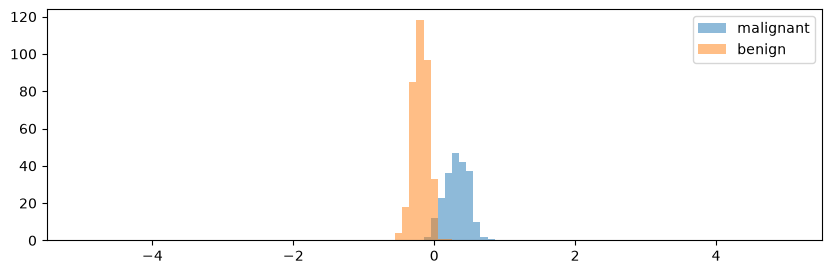

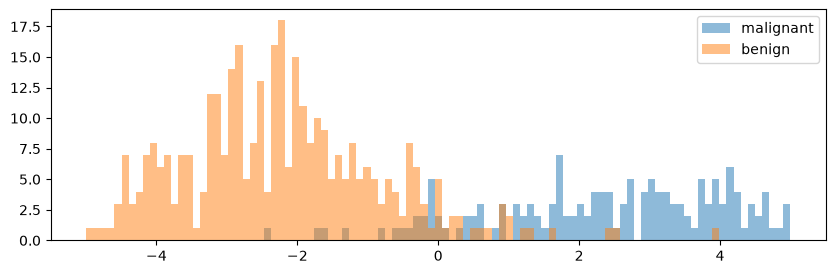

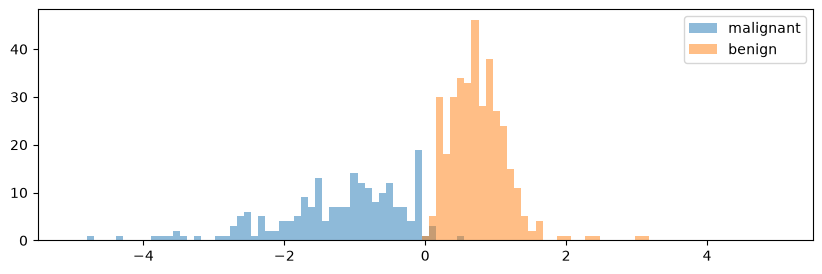

In [5]:
import matplotlib.pyplot as plt
import sklearn
import sklearn.svm
def plot(w):
    w = w / (w**2).sum()**.5
    ZM = XM.dot(w)
    ZB = XB.dot(w)
    l = numpy.linspace(-5,5,100)
    plt.figure(figsize=(10,3))
    plt.hist(ZM, bins =l, label= 'malignant', alpha=.5)
    plt.hist(ZB, bins=l, label='benign', alpha=.5)
    plt.legend()
    plt.show()
plot(fisher(XM,XB))
plot(XM.mean(axis=0)-XB.mean(axis=0))

plot(sklearn.svm.SVC(C=10, kernel='linear').fit(X,T).coef_[0])

Observe that different discriminants extract different aspects of the data. For example, the difference of means algorithm produces the highest average distance between classes. The Fisher vector produces rather small distance between classes but also very low variance within classes. Lastly, the SVM focuses on achieving a low overlap between the two classes through learning a separating hyperplane.